Dataset shape: (109, 4)

Columns:
['dataset', 'accuracy', 'time_training_seconds', 'time_test_seconds']

First 5 rows:


,dataset,accuracy,time_training_seconds,time_test_seconds
0,ACSF1,0.822333,0.49,0.25
1,Adiac,0.801705,0.45,0.23
2,ArrowHead,0.880952,0.13,0.14
3,BME,0.992222,0.11,0.07
4,Beef,0.761111,0.17,0.04



Data types:
dataset                      str
accuracy                 float64
time_training_seconds    float64
time_test_seconds        float64
dtype: object

Possible text columns:
0 : dataset

Selected text column: dataset

Original vs cleaned text:


,dataset,clean_text
0,ACSF1,acsf
1,Adiac,adiac
2,ArrowHead,arrowhead
3,BME,bme
4,Beef,beef



Dataset after removing empty text:
(109, 5)

TF-IDF matrix shape: (109, 4)
k = 2, silhouette score = 0.9084
k = 3, silhouette score = 0.9385
k = 4, silhouette score = 0.9690
k = 5, silhouette score = 1.0000
k = 6, silhouette score = 1.0000
k = 7, silhouette score = 1.0000
k = 8, silhouette score = 1.0000
k = 9, silhouette score = 1.0000
k = 10, silhouette score = 1.0000


/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/base.py:1403: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/base.py:1403: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (7). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/base.py:1403: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/base.py:1403: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (9). Possibl

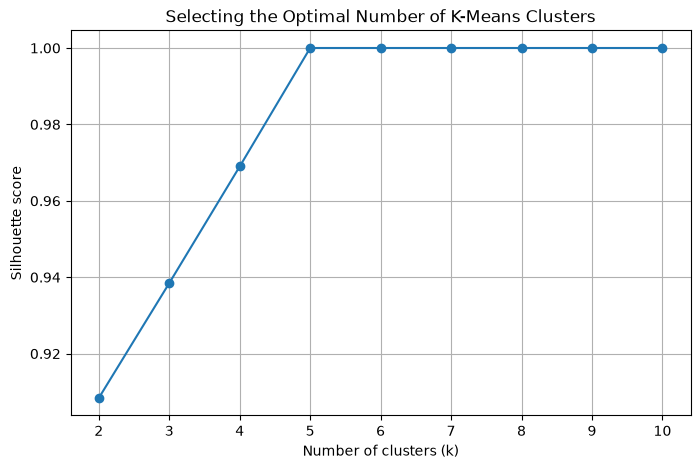


Best number of clusters: 5
Best silhouette score: 1.0

Cluster counts:
cluster
0    101
1      2
2      2
3      2
4      2
Name: count, dtype: int64

CLUSTER 0
- ACSF1
- Adiac
- ArrowHead
- BME
- Beef

CLUSTER 1
- ToeSegmentation1
- ToeSegmentation2

CLUSTER 2
- ECG200
- ECG5000

CLUSTER 3
- SonyAIBORobotSurface1
- SonyAIBORobotSurface2

CLUSTER 4
- Lightning2
- Lightning7

Top terms for each cluster:

Cluster 0:
toesegmentation, sonyaiborobotsurface, lightning, ecg

Cluster 1:
toesegmentation, sonyaiborobotsurface, lightning, ecg

Cluster 2:
ecg, toesegmentation, sonyaiborobotsurface, lightning

Cluster 3:
sonyaiborobotsurface, toesegmentation, lightning, ecg

Cluster 4:
lightning, toesegmentation, sonyaiborobotsurface, ecg


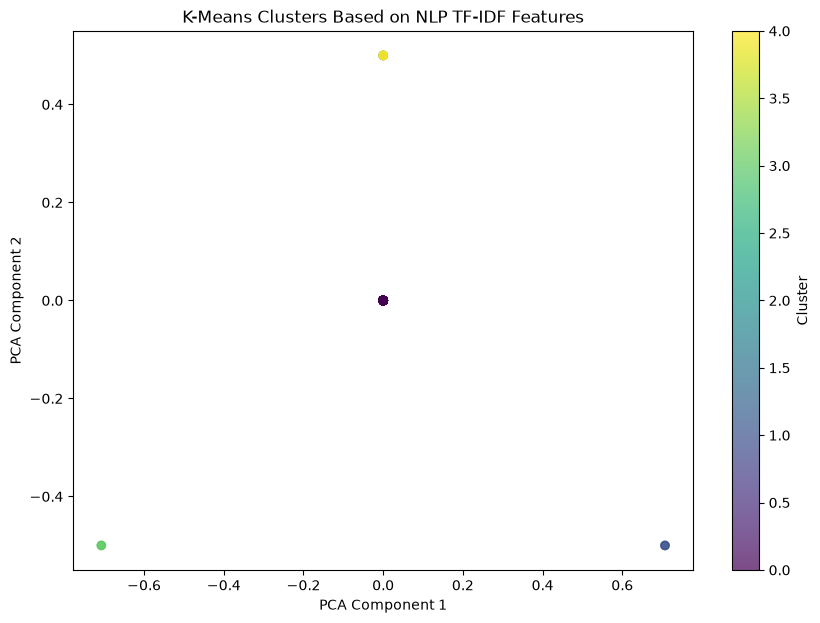


Cluster summary:


,cluster,number_of_documents
0,0,101
1,1,2
2,2,2
3,3,2
4,4,2



Saved clustered dataset:
results_ucr109_mean_kmeans.csv


,dataset,accuracy,time_training_seconds,time_test_seconds,clean_text,cluster
0,ACSF1,0.822333,0.49,0.25,acsf,0
1,Adiac,0.801705,0.45,0.23,adiac,0
2,ArrowHead,0.880952,0.13,0.14,arrowhead,0
3,BME,0.992222,0.11,0.07,bme,0
4,Beef,0.761111,0.17,0.04,beef,0


In [1]:
# ============================================================
# K-MEANS + NLP CLUSTERING FOR results_ucr109_mean.csv
# ============================================================

# If needed, install packages in Jupyter:
# !pip install pandas numpy scikit-learn matplotlib seaborn nltk wordcloud

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------

file_path = "results_ucr109_mean.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

# ------------------------------------------------------------
# 2. Find text column
# ------------------------------------------------------------

# Display data types
print("\nData types:")
print(df.dtypes)

# Automatically select object/string columns
text_columns = df.select_dtypes(include=["object", "string"]).columns.tolist()

if len(text_columns) == 0:
    raise ValueError(
        "No text column was found. Please specify the column containing text manually."
    )

print("\nPossible text columns:")
for i, col in enumerate(text_columns):
    print(i, ":", col)

# ------------------------------------------------------------
# IMPORTANT:
# If the automatic choice is wrong, change this line.
# Example:
# text_column = "description"
# ------------------------------------------------------------

text_column = text_columns[0]

print("\nSelected text column:", text_column)

# Convert missing values to empty strings
df[text_column] = df[text_column].fillna("").astype(str)

# ------------------------------------------------------------
# 3. NLP text cleaning
# ------------------------------------------------------------

def clean_text(text):
    """
    Basic NLP preprocessing:
    - lowercase
    - remove URLs
    - remove punctuation
    - remove numbers
    - remove extra whitespace
    """
    
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    
    # Remove punctuation/special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


df["clean_text"] = df[text_column].apply(clean_text)

print("\nOriginal vs cleaned text:")
display(df[[text_column, "clean_text"]].head())

# ------------------------------------------------------------
# 4. Remove empty documents
# ------------------------------------------------------------

df = df[df["clean_text"].str.len() > 0].copy()

print("\nDataset after removing empty text:")
print(df.shape)

# ------------------------------------------------------------
# 5. Convert text into TF-IDF features
# ------------------------------------------------------------

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df["clean_text"])

print("\nTF-IDF matrix shape:", X.shape)

# ------------------------------------------------------------
# 6. Find the best number of clusters
# ------------------------------------------------------------

# Test different numbers of clusters
max_k = min(10, len(df) - 1)

k_values = range(2, max_k + 1)

silhouette_scores = []

for k in k_values:
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X)
    
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    
    print(f"k = {k}, silhouette score = {score:.4f}")

# ------------------------------------------------------------
# 7. Plot silhouette scores
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Selecting the Optimal Number of K-Means Clusters")

plt.grid(True)
plt.show()

# Select k with highest silhouette score
best_k = list(k_values)[np.argmax(silhouette_scores)]

print("\nBest number of clusters:", best_k)
print(
    "Best silhouette score:",
    round(max(silhouette_scores), 4)
)

# ------------------------------------------------------------
# 8. Perform final K-Means clustering
# ------------------------------------------------------------

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X)

print("\nCluster counts:")
print(df["cluster"].value_counts().sort_index())

# ------------------------------------------------------------
# 9. Examine documents in each cluster
# ------------------------------------------------------------

for cluster in sorted(df["cluster"].unique()):
    
    print("\n" + "=" * 70)
    print("CLUSTER", cluster)
    print("=" * 70)
    
    cluster_data = df[df["cluster"] == cluster]
    
    for text in cluster_data[text_column].head(5):
        print("-", text)

# ------------------------------------------------------------
# 10. Identify important words in each cluster
# ------------------------------------------------------------

terms = tfidf.get_feature_names_out()

print("\nTop terms for each cluster:")

for cluster_number in range(best_k):
    
    center = kmeans.cluster_centers_[cluster_number]
    
    top_indices = center.argsort()[-15:][::-1]
    
    top_words = [terms[i] for i in top_indices]
    
    print(f"\nCluster {cluster_number}:")
    print(", ".join(top_words))

# ------------------------------------------------------------
# 11. Visualise clusters using PCA
# ------------------------------------------------------------

# PCA requires a dense matrix
# Limit dimensions first for large datasets

X_dense = X.toarray()

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_dense)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["cluster"],
    alpha=0.7
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters Based on NLP TF-IDF Features")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.show()

# ------------------------------------------------------------
# 12. Cluster summary
# ------------------------------------------------------------

cluster_summary = (
    df.groupby("cluster")
      .size()
      .reset_index(name="number_of_documents")
)

print("\nCluster summary:")
display(cluster_summary)

# ------------------------------------------------------------
# 13. Save results
# ------------------------------------------------------------

output_file = "results_ucr109_mean_kmeans.csv"

df.to_csv(
    output_file,
    index=False
)

print("\nSaved clustered dataset:")
print(output_file)

# ------------------------------------------------------------
# 14. Display final dataset
# ------------------------------------------------------------

display(df.head())